# Phase 4b: Naïve Bayes Model (Balanced with SMOTE)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import label_binarize
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid")
plt.rcParams.update({'figure.autolayout': True})

print("Loading preprocessed dataset from Phase 2...")
df = pd.read_csv('../outputs/processed_imbalanced_data.csv')
print(f"Loaded {df.shape[0]:,} rows and {df.shape[1]} columns.")

Loading preprocessed dataset from Phase 2...
Loaded 502,346 rows and 80 columns.


### Step 1: Train/Test Split

In [2]:
X = df.drop('Severity', axis=1)
y = df['Severity']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set: {X_train.shape[0]:,} rows.")
print(f"Testing set:  {X_test.shape[0]:,} rows.")

Training set: 401,876 rows.
Testing set:  100,470 rows.


### Step 2: Apply SMOTE to Training Data ONLY

In [3]:
print("Applying SMOTE to training data ONLY...")
smote = SMOTE(random_state=42)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train, y_train)

print(f"Training set (After SMOTE): {X_train_balanced.shape[0]:,} rows.")

Applying SMOTE to training data ONLY...
Training set (After SMOTE): 1,280,428 rows.


### Train the Naïve Bayes Model (GaussianNB)

In [4]:
print("Training Gaussian Naïve Bayes Model on balanced data...")
nb_model = GaussianNB()
nb_model.fit(X_train_balanced, y_train_balanced)
print("Training Complete!")

Training Gaussian Naïve Bayes Model on balanced data...
Training Complete!


### Evaluate on the UNTOUCHED Test Set

In [5]:
y_pred = nb_model.predict(X_test)
y_prob = nb_model.predict_proba(X_test)

print("--- Naïve Bayes Evaluation Metrics ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")

--- Naïve Bayes Evaluation Metrics ---
Accuracy:  0.0661
Precision: 0.7700
Recall:    0.0661
F1 Score:  0.0775


### Confusion Matrix

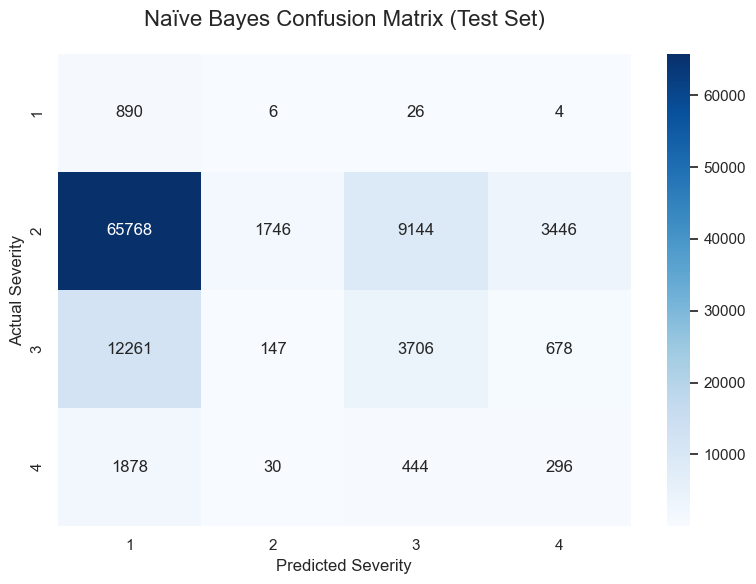

In [6]:
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[1, 2, 3, 4], yticklabels=[1, 2, 3, 4])
plt.title('Naïve Bayes Confusion Matrix (Test Set)', fontsize=16, pad=20)
plt.ylabel('Actual Severity', fontsize=12)
plt.xlabel('Predicted Severity', fontsize=12)
plt.show()

### ROC Curve (Predicting Fatal Accidents)

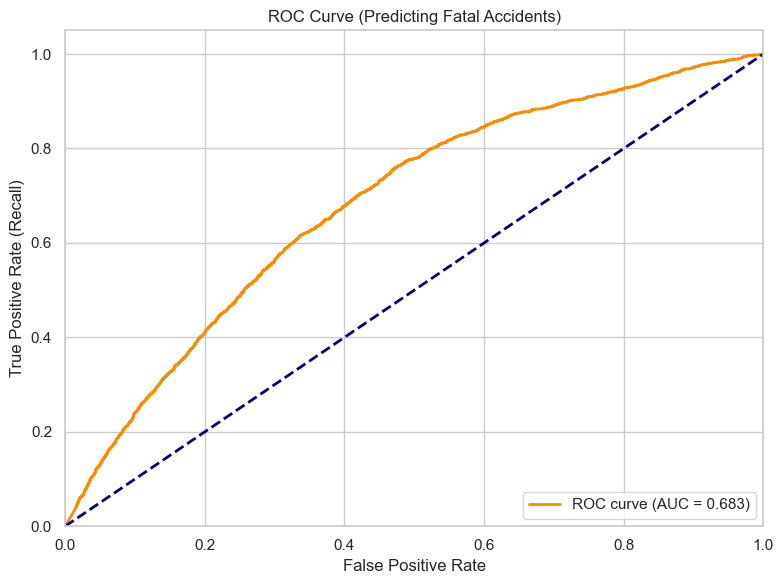

In [7]:
y_test_bin = label_binarize(y_test, classes=[1, 2, 3, 4])
fatal_class_idx = 3 # Index for Severity 4

fpr, tpr, _ = roc_curve(y_test_bin[:, fatal_class_idx], y_prob[:, fatal_class_idx])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve (Predicting Fatal Accidents)')
plt.legend(loc="lower right")
plt.show()

### Class Prior Probabilities
Naïve Bayes calculates the baseline probability of each class before looking at any features. Let's visualize what it learned.

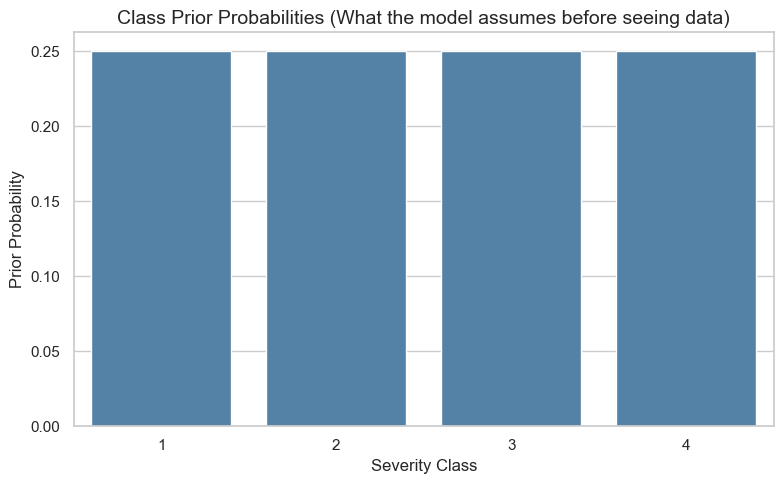

Base probability of Severity 1: 25.00%
Base probability of Severity 2: 25.00%
Base probability of Severity 3: 25.00%
Base probability of Severity 4: 25.00%


In [8]:
priors = nb_model.class_prior_
classes = nb_model.classes_

plt.figure(figsize=(8, 5))
sns.barplot(x=classes, y=priors, color='steelblue')
plt.title("Class Prior Probabilities (What the model assumes before seeing data)", fontsize=14)
plt.xlabel("Severity Class")
plt.ylabel("Prior Probability")
plt.show()

for c, p in zip(classes, priors):
    print(f"Base probability of Severity {c}: {p*100:.2f}%")